In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
from mask2bbox import BBoxes
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
ref_path = Path("/Users/miguelibarra/PycharmProjects/micronuclei_labeling_tool/out/labels_small_refined.csv").resolve()
raw_path = Path("/Users/miguelibarra/PycharmProjects/micronuclei_labeling_tool/out/labels_small_raw.csv").resolve()
ref = pd.read_csv(ref_path)
raw = pd.read_csv(raw_path)

In [3]:
# Merge
combined = pd.merge(on="image", left=ref, right=raw, suffixes=("_ref", "_raw"))
combined

,image,count_ref,label_ref,count_raw,label_raw
0,s01c1_1.png,0,0,0,0
1,s01c1_2.png,1,1,1,1
2,s01c1_3.png,3,1,3,1
3,s01c1_4.png,0,0,0,0
4,s01c1_5.png,0,0,0,0
...,...,...,...,...,...
20080,s06c1_4369.png,0,0,0,0
20081,s06c1_4370.png,0,0,0,0
20082,s06c1_4371.png,0,0,0,0
20083,s06c1_4372.png,0,0,0,0


In [4]:
# Get
combined["im"] = combined["image"].apply(lambda x: x.split("_")[0])
combined

,image,count_ref,label_ref,count_raw,label_raw,im
0,s01c1_1.png,0,0,0,0,s01c1
1,s01c1_2.png,1,1,1,1,s01c1
2,s01c1_3.png,3,1,3,1,s01c1
3,s01c1_4.png,0,0,0,0,s01c1
4,s01c1_5.png,0,0,0,0,s01c1
...,...,...,...,...,...,...
20080,s06c1_4369.png,0,0,0,0,s06c1
20081,s06c1_4370.png,0,0,0,0,s06c1
20082,s06c1_4371.png,0,0,0,0,s06c1
20083,s06c1_4372.png,0,0,0,0,s06c1


In [5]:
combined["id"] = combined["image"].apply(lambda x: x.split("_")[1].split(".")[0])
combined

,image,count_ref,label_ref,count_raw,label_raw,im,id
0,s01c1_1.png,0,0,0,0,s01c1,1
1,s01c1_2.png,1,1,1,1,s01c1,2
2,s01c1_3.png,3,1,3,1,s01c1,3
3,s01c1_4.png,0,0,0,0,s01c1,4
4,s01c1_5.png,0,0,0,0,s01c1,5
...,...,...,...,...,...,...,...
20080,s06c1_4369.png,0,0,0,0,s06c1,4369
20081,s06c1_4370.png,0,0,0,0,s06c1,4370
20082,s06c1_4371.png,0,0,0,0,s06c1,4371
20083,s06c1_4372.png,0,0,0,0,s06c1,4372


In [6]:
# Check the ones where label ref and label raw are different
different = combined[combined["label_ref"] != combined["label_raw"]]

# Get value counts and sort by index
counts = different["im"].value_counts().sort_index()

In [7]:
counts

im
s01c1    121
s02c1    130
s03c1    127
s04c1    314
s05c1    204
s06c1    215
Name: count, dtype: int64

In [16]:
# Get the ones where label ref is 0 and label raw is 1
# These are the ones that were missed
missed = different[(different["label_ref"] == 0) & (different["label_raw"] == 1)]

In [17]:
missed[missed["im"]== "s02c1"]

,image,count_ref,label_ref,count_raw,label_raw,im,id
2280,s02c1_444.png,0,0,1,1,s02c1,444


In [18]:
im = "s02c1"
bboxes = BBoxes.from_mask(f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/week3/segmentation/stardist/{im}.tif")
bboxes.image = f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/week3/ometif/{im}.ome.tif"
boxes = bboxes.expand(15)

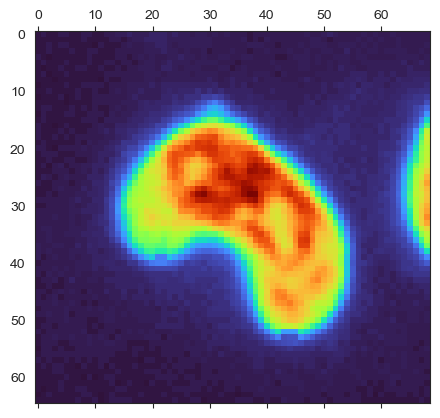

In [19]:
id = 2112
sns.set_style("white")
plt.matshow(boxes.grab(id, to="image"), cmap="turbo")

In [20]:
boxes = BBoxes.from_mask(f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/week3/segmentation/stardist/{im}.tif")
boxes.image = f"/Users/miguelibarra/PycharmProjects/cin/data/Lindsay/week3/ometif/{im}.ome.tif"

size = (96, 96)
rf = boxes.calculate_resizing_factor(0.5, size)
boxes = boxes.expand(30)

In [21]:
np.mean(boxes.get("sides"), axis=0)

array([1123.        ,   92.13051225,   92.92694878])

In [22]:
def plot_crop_grid(data, cols=8, cmap="turbo"):
    # Estimate the number of rows needed for the plot
    rows = len(data)//cols if len(data)%cols==0 else len(data)//cols+1

    # Plot
    sns.set_style("white")
    fig, ax = plt.subplots(rows, cols, figsize=(3*cols, 3*rows), )
    for i,(ix, j) in enumerate(data.iterrows()):
        cell_id = int(j.id)-1
        ax[ i//cols, i%cols].matshow(boxes.extract_single(cell_id, rf[cell_id], size), cmap=cmap)
        ax[ i//cols, i%cols].set_title(f"{j.image}")
        # ax[ i//cols, i%cols].set_title(f"{int(j.image)} = T: {j['count']:.0f} - {j['micronuclei']:.0f} P\n{j['score']}")
        ax[ i//cols, i%cols].set_yticks([])
        ax[ i//cols, i%cols].set_xticks([])

    sns.despine(left=True, bottom=True)
    fig.tight_layout()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

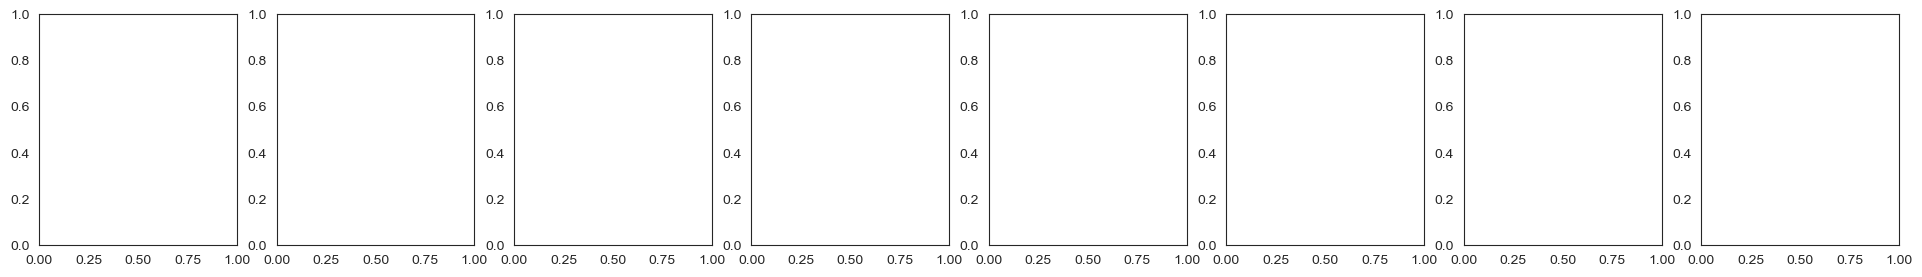

In [23]:
plot_crop_grid(missed[missed["im"]==im], cols=8, cmap="turbo")